## Version 4.0 after discussion with Guoming

Trying new clustering method, add dimensionality

In [1]:
import warnings
warnings.filterwarnings('ignore')

from util.util_clustering import *
from util.util import *
from util.util_montage import *

In [2]:
debug = False

# Hardcoded path for easier running
folder_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data"
# Look up all subfolders in the data folder
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir() and not f.name.startswith('.')]
subfolders.sort()  # Sort the subfolders alphabetically

print(f"Found {len(subfolders)} subfolders in the data folder.")
i = 0
for subfolder in subfolders:
    print(f"    {i}: {subfolder.split('/')[-1]}")
    i += 1

Found 10 subfolders in the data folder.
    0: 2x_4EGI1
    1: 2x_CHX
    2: 2x_Har
    3: 2x_puro
    4: THOR_1x
    5: THOR_2x
    6: THORdel_2x
    7: THORdelta_1x
    8: mRNA-1x
    9: mRNA_2x


In [3]:
# Define the name for this combined dataset      
# data_name = 'translation_inhibited'
data_name = 'hypertonic'

In [4]:
# Change this index to select different subfolders
indexes = [9]  # Example: [0, 1] to select the first two subfolders
legend_bool = False

In [5]:
# Define empty DataFrames to hold combined data
df_tracks_combined = pd.DataFrame()
df_condensates_combined = pd.DataFrame()
data_names = []

for index in indexes:    
    data_path = subfolders[index]
    data_name = data_path.split("/")[-1]
    data_names.append(data_name)
    print(f"Selected data for {data_name} in folder: {data_path}")

    file_pairs = find_matching_files(data_path)

    all_tracks = []
    all_condensates = []

    for rna_path, condensate_path, exp_name in track(file_pairs, description="Loading datasets"):
        df_tracks, df_condensates = load_dataset_pair(rna_path, condensate_path, exp_name)
        
        if df_tracks is not None and df_condensates is not None:
            all_tracks.append(df_tracks)
            all_condensates.append(df_condensates)

    if all_tracks and all_condensates:
        # Add the result to the combined DataFrames
        df_tracks_combined = pd.concat([df_tracks_combined] + all_tracks, ignore_index=True)
        df_condensates_combined = pd.concat([df_condensates_combined] + all_condensates, ignore_index=True)
        
        if debug:
            print(f"✅ Successfully loaded and combined:")
            print(f"   - {len(df_tracks_combined)} total track points")
            print(f"   - {len(df_condensates_combined)} total condensate entries")
            print(f"   - {df_tracks_combined['experiment'].nunique()} experiments")

        # Display summary statistics
        if debug:
            print("\n📊 Dataset Summary:")
        for exp in df_tracks_combined['experiment'].unique():
            exp_tracks = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            exp_condensates = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            if debug:
                print(f"   {exp}: {exp_tracks['trackID'].nunique()} tracks, "
                        f"{len(exp_condensates)} condensate entries")

Output()

Selected data for mRNA_2x in folder: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data/mRNA_2x


In [6]:
common_time = np.linspace(0, 20, 200)  # Common time vector for interpolation

In [7]:
plot_labels = ['Escape', 'Outer Boundary', 'Inner Boundary', 'Confined']

Found 3 files matching patterns ['mRNA_2x'] in result.
Loaded mRNA_2x_rna_condensate_distances.csv with 49215 tracks.
Loaded 20220508-FLmRNA_2x.csv with 8515 tracks.
Loaded mRNA_2x_filtered_rna_condensate_distances.csv with 8515 tracks.
Data prepared successfully. Processed traces shape: (66245, 200)
Number of original traces: 66245


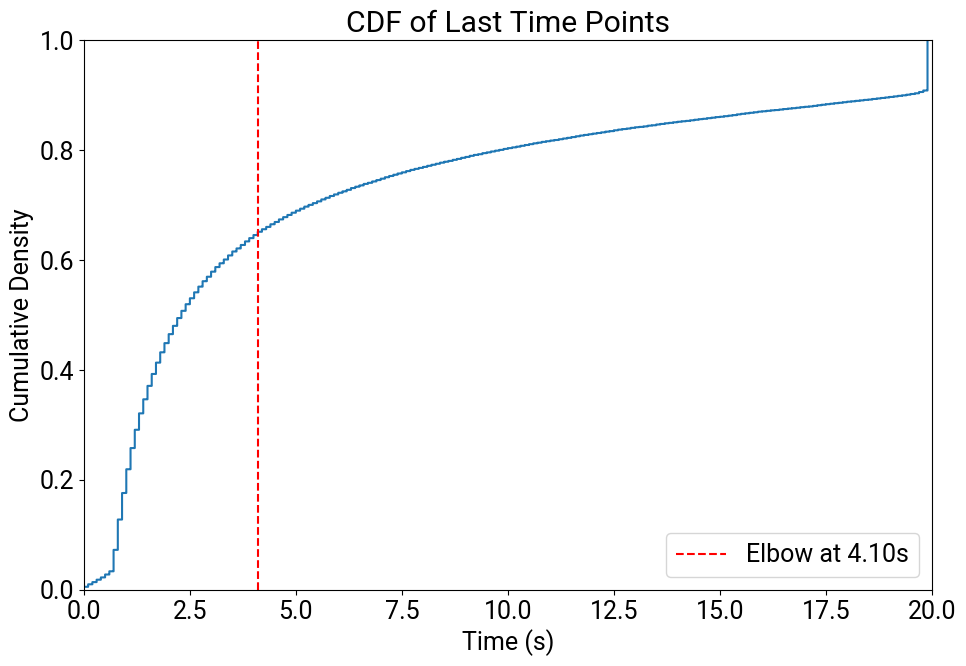

Elbow point at index 43169 with last time 4.10s
Setting t_max to 4 seconds based on CDF analysis.
Filtered data matrix shape: (28439, 30)
Filtered traces shape: 28439


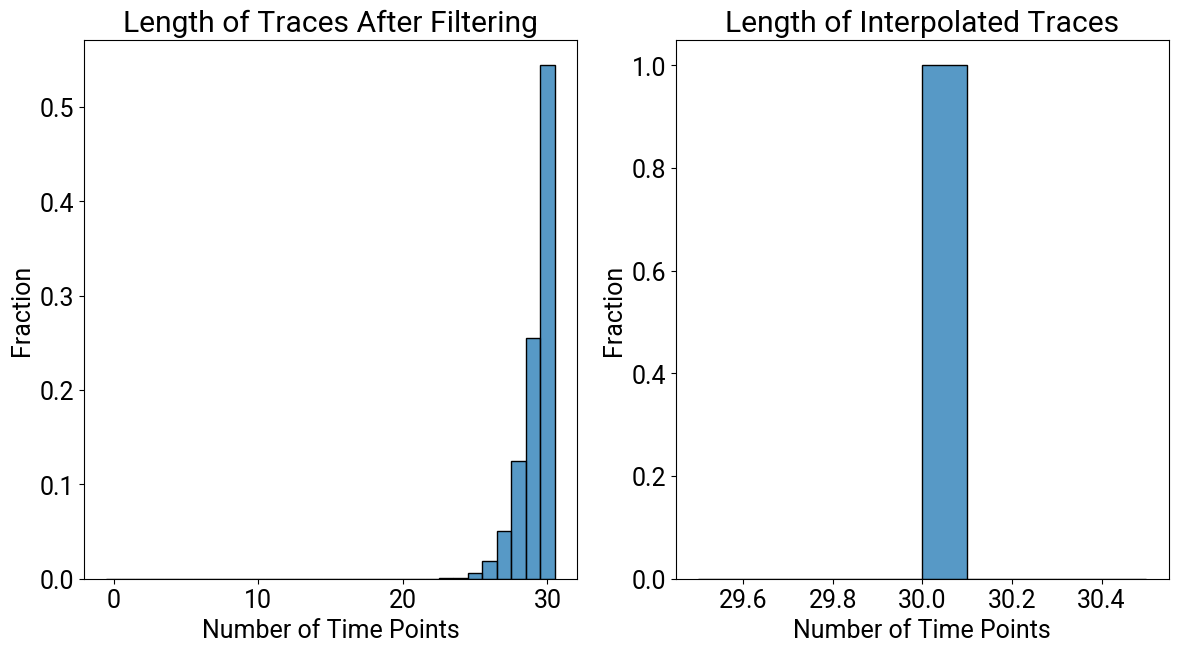

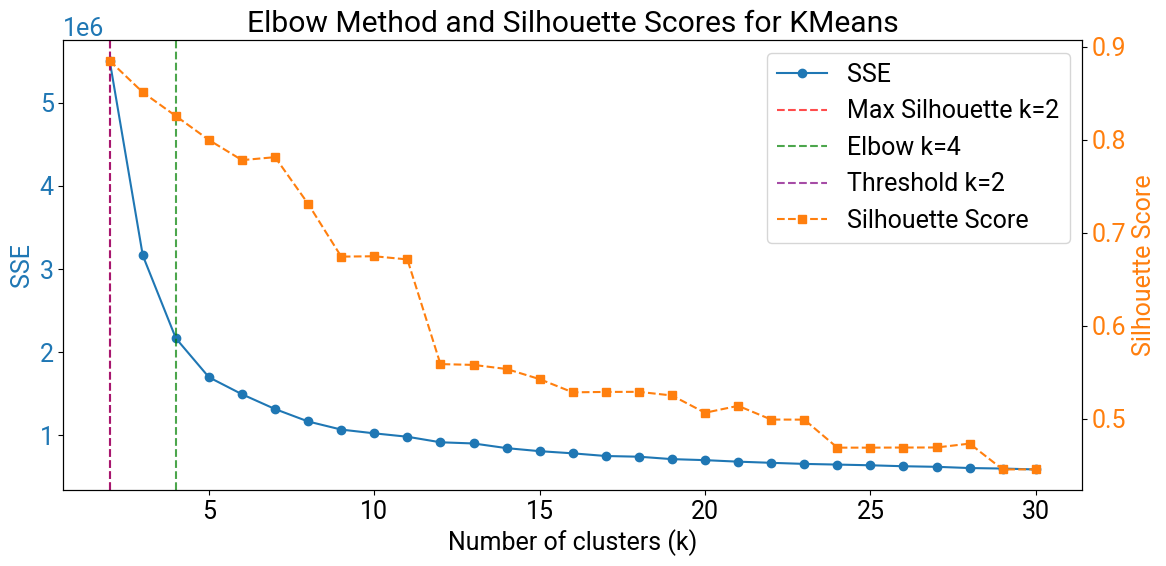

Optimal k recommendations:
  Max Silhouette Score: 2
  Elbow Method: 4
  Silhouette Threshold: 2

Recommended k: 4
Assigned data to 4 clusters using KMeans.
Cluster 0: 4585 traces (16.1%)
Cluster 1: 11780 traces (41.4%)
Cluster 2: 6497 traces (22.8%)
Cluster 3: 5577 traces (19.6%)
Total traces: 28439


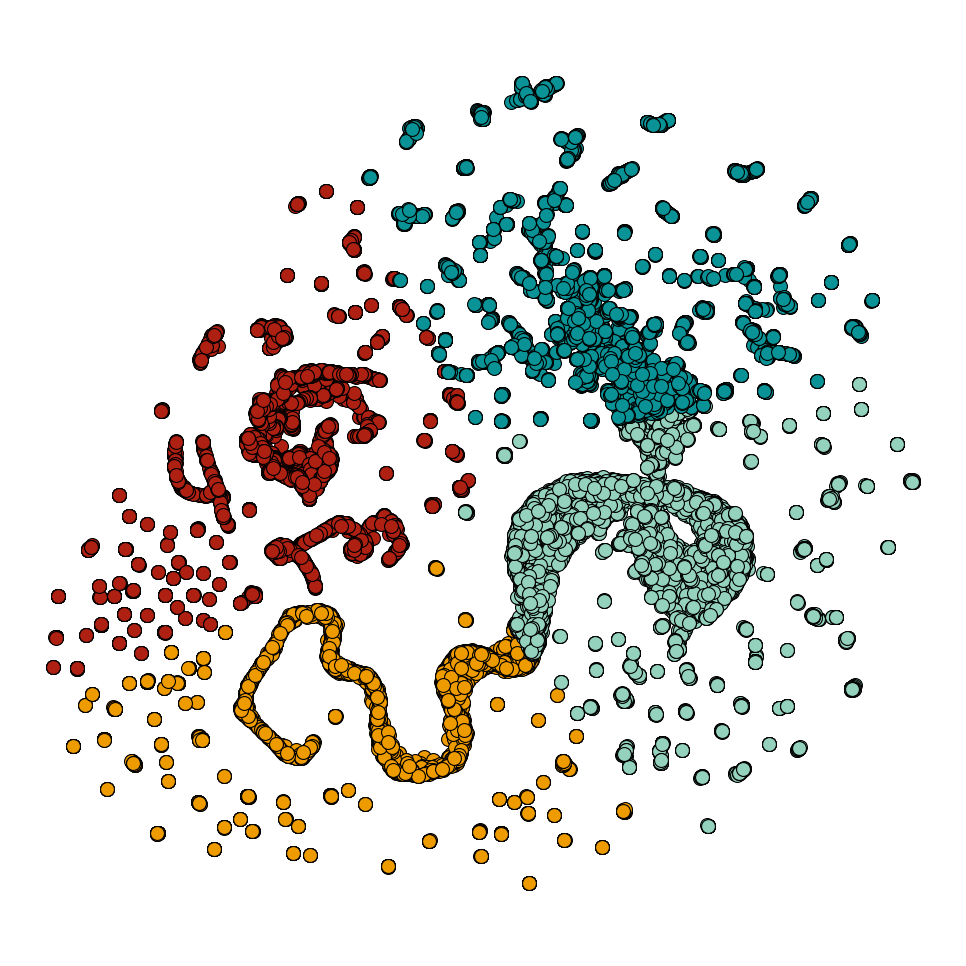

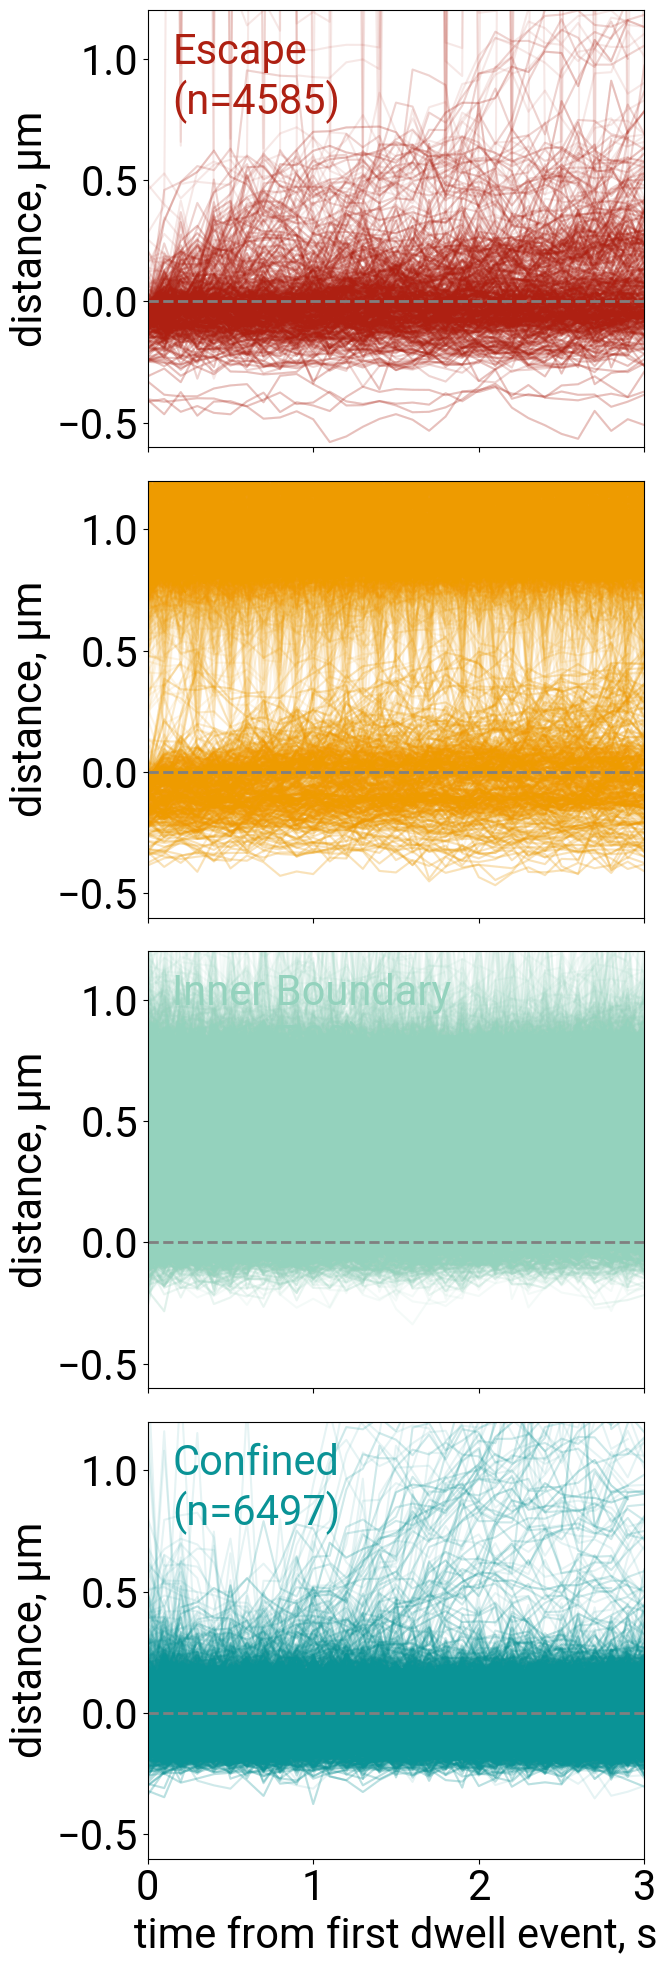

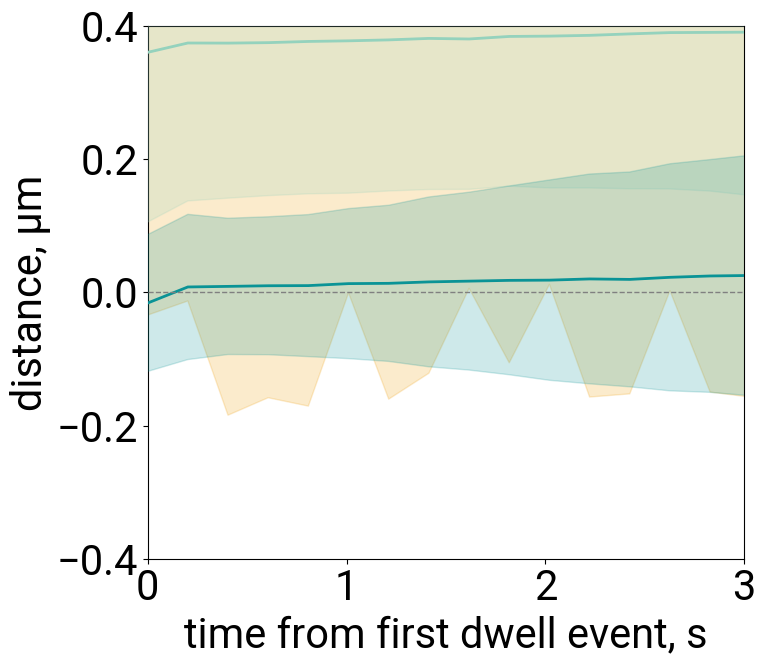

In [8]:
# Load your data
# Make sure your files are in a folder named 'sample_trajectories' or change the path
try:
    processed_traces, original_traces = load_and_prepare_multiple_trajectories('result', common_time=common_time, file_patterns=data_names)
    print(f"Data prepared successfully. Processed traces shape: {processed_traces.shape}")

    # Print the shape of the original traces
    print(f"Number of original traces: {len(original_traces)}")
    
    first_time_list, last_time_list = find_duration_histogram(original_traces)

    t_max = find_trajectory_elbow_point(original_traces, show_plot=True)

    t_max = 3  # Set a maximum time threshold based on the CDF analysis
    
    processed_traces, filtered_traces, length_matrix, interp_length_matrix = filter_and_interpolate_traces(original_traces, t_max=t_max, show_plot=True)
    
    # Find the optimal number of clusters
    optimal_results = optimal_kmeans(processed_traces, max_k=30)
    
    print(f"Optimal k recommendations:")
    print(f"  Max Silhouette Score: {optimal_results['max_silhouette']}")
    print(f"  Elbow Method: {optimal_results['elbow']}")
    print(f"  Silhouette Threshold: {optimal_results['threshold']}")

    # Use the max silhouette score as default
    optimal_k = optimal_results['elbow']
    # optimal_k = 3 # Override
    print(f"\nRecommended k: {optimal_k}")
    
    cluster_labels, embedding, cluster_df = perform_clustering(processed_traces,
                                                               filtered_traces,
                                                               optimal_k,
                                                               plot_labels=plot_labels,
                                                               data_name=data_name,
                                                               n_neighbors=5,
                                                               t_max=t_max,
                                                               n_rows_cols=[4, 1],
                                                               legend=legend_bool,
                                                               savefig_format='svg',
                                                               plot_cluster=True)    
except FileNotFoundError:
    print("Error: 'sample_trajectories' folder not found. Please create it and add your data files, or run the `create_synthetic_data()` function first.")

In [9]:
cluster_df

,cluster_label,rank,representative_trace,mean_distance,std_distance,count_above_threshold,plot_labels
0,0,1,experiment trackID ...,"[11.202546353171819, 10.711871160484012, 10.93...","[9.420198055990365, 8.869383284810263, 8.97376...",3649,Escape
1,3,2,experiment trackID ...,"[1.565774811848492, 1.5734920683833467, 1.5985...","[1.5999003918761951, 1.5864473643403727, 1.782...",4631,Outer Boundary
2,1,3,experiment trackID ...,"[0.3604320896738579, 0.37446062324486673, 0.37...","[0.25489681719179036, 0.23715598368569246, 0.2...",6245,Inner Boundary
3,2,4,experiment trackID ...,"[-0.01604447953117652, 0.008099995686354845, 0...","[0.10271896024404731, 0.1090460081061714, 0.10...",172,Confined


In [10]:
cluster_dict = {
    'cluster_id': [],
    'experiment': [],
    'trackID': [],
    'track_df': [],
    'trace_df': [],
    'condensate_df': [],
    'exp_result': [],
}

# Cluster_reps: Dictionary to hold representative trajectories for each cluster
cluster_reps = {
    '0': cluster_df[cluster_df['cluster_label'] == 0].iloc[[0]]['representative_trace'].values[0],
    '1': cluster_df[cluster_df['cluster_label'] == 1].iloc[[0]]['representative_trace'].values[0],
    '2': cluster_df[cluster_df['cluster_label'] == 2].iloc[[0]]['representative_trace'].values[0],
    '3': cluster_df[cluster_df['cluster_label'] == 3].iloc[[0]]['representative_trace'].values[0],
}

# Plot the representative trajectories snapshots
for cluster_id, rep_trace in cluster_reps.items():
    # Locate the condensate_df and track_df for this experiment
    exp, track_id = rep_trace['experiment'].iloc[0], rep_trace['trackID'].iloc[0]
    
    print(f"Cluster {cluster_id} representative trajectory: {exp}, Track ID: {track_id}")
    
    try:
        # Load the specific data for this experiment and track
        track_df = df_tracks_combined[(df_tracks_combined['experiment'] == exp) & (df_tracks_combined['trackID'] == track_id)]
        
        plot_label = cluster_df[cluster_df['cluster_label'] == int(cluster_id)].iloc[[0]]['plot_labels'].values[0]
        
        # Locate the trace_df in filtered_traces
        temp_trace = pd.DataFrame()  # Initialize an empty DataFrame
        for trace in filtered_traces:
            if (trace['experiment'].iloc[0] == exp) and (trace['trackID'].iloc[0] == track_id):
                temp_trace = trace
                break
        
        trace_df = temp_trace
        
        print(f"    [Trace] Experiment: {trace_df['experiment'].iloc[0]} Track ID: {trace_df['trackID'].iloc[0]}", end="\n\n")
        
        condensate_df = df_condensates_combined[df_condensates_combined['experiment'] == exp]

        # Analyze interactions
        experiment_result = legacy_analyze_interactions(track_df, condensate_df, proximity_threshold=1)
        
        # Create the snapshot
        plot_trajectory_snapshots(df_tracks=track_df,
                                  exp_results=experiment_result,
                                  trace_df=trace_df,
                                  window_size_um=2,
                                  um_per_pixel=um_per_pixel,
                                  save_path=f'result/trajectory_snapshot/{data_name}_{plot_label}.png')
                                #   title=f"{plot_label}")
        
        # Store in the cluster dictionary
        cluster_dict['cluster_id'].append(cluster_id)
        cluster_dict['experiment'].append(exp)
        cluster_dict['trackID'].append(track_id)
        cluster_dict['track_df'].append(track_df)
        cluster_dict['trace_df'].append(trace_df)
        cluster_dict['condensate_df'].append(condensate_df)
        cluster_dict['exp_result'].append(experiment_result)

        print(f"Snapshot created for {exp}, Track ID: {track_id}", end="\n\n")
        
    except KeyError:
        print(f"Error: Experiment {exp} not found in the combined dataframes.")
        continue

Cluster 0 representative trajectory: 20220508-FLmRNA_2x_FOV-12, Track ID: 406
    [Trace] Experiment: 20220508-FLmRNA_2x_FOV-12 Track ID: 406



NameError: name 'legacy_analyze_interactions' is not defined

In [ ]:
# Create a color palette
unique_labels = np.unique(cluster_labels)

# Use color_palette.py to get a consistent color mapping based on rank
color_palette = get_color_palette(n=len(unique_labels))  # Exclude noise
cluster_rank = cluster_df[['cluster_label', 'rank']]
color_map = {row['cluster_label']: color_palette[row['rank'] - 1] for _, row in cluster_rank.iterrows()}

print(color_map)

{1: '#AE2012', 3: '#EE9B00', 0: '#94D2BD', 2: '#0A9396'}


In [ ]:
cluster_df.loc[0]

cluster_label                                                            1
rank                                                                     1
representative_trace                        experiment  trackID    t  d...
mean_distance            [-0.04138494656249313, 0.05525752802800742, 0....
std_distance             [0.05664735206619368, 0.14297218663846026, 0.1...
count_above_threshold                                                  435
plot_labels                                                         Escape
Name: 0, dtype: object

In [ ]:
cluster_df.loc[0]['representative_trace']

,experiment,trackID,t,distance_um,t_dwell,t_original
92036,20220512-FL_2x_CHX_FOV,204,0.0,-0.024644,2.3,2.3
92037,20220512-FL_2x_CHX_FOV,204,0.1,-0.046302,2.3,2.4
92038,20220512-FL_2x_CHX_FOV,204,0.2,-0.002125,2.3,2.5
92039,20220512-FL_2x_CHX_FOV,204,0.3,0.137520,2.3,2.6
92040,20220512-FL_2x_CHX_FOV,204,0.4,0.153078,2.3,2.7
92041,20220512-FL_2x_CHX_FOV,204,0.5,0.137436,2.3,2.8
92042,20220512-FL_2x_CHX_FOV,204,0.6,0.141104,2.3,2.9
92043,20220512-FL_2x_CHX_FOV,204,0.7,0.083010,2.3,3.0
92044,20220512-FL_2x_CHX_FOV,204,0.8,0.177168,2.3,3.1
92045,20220512-FL_2x_CHX_FOV,204,1.0,0.150189,2.3,3.3


Max y-axis limit: 3.0
Combined trajectory plot saved to result/combined_trajectories/20220629-FL_2x_puro_combined_cluster_trajectories.svg


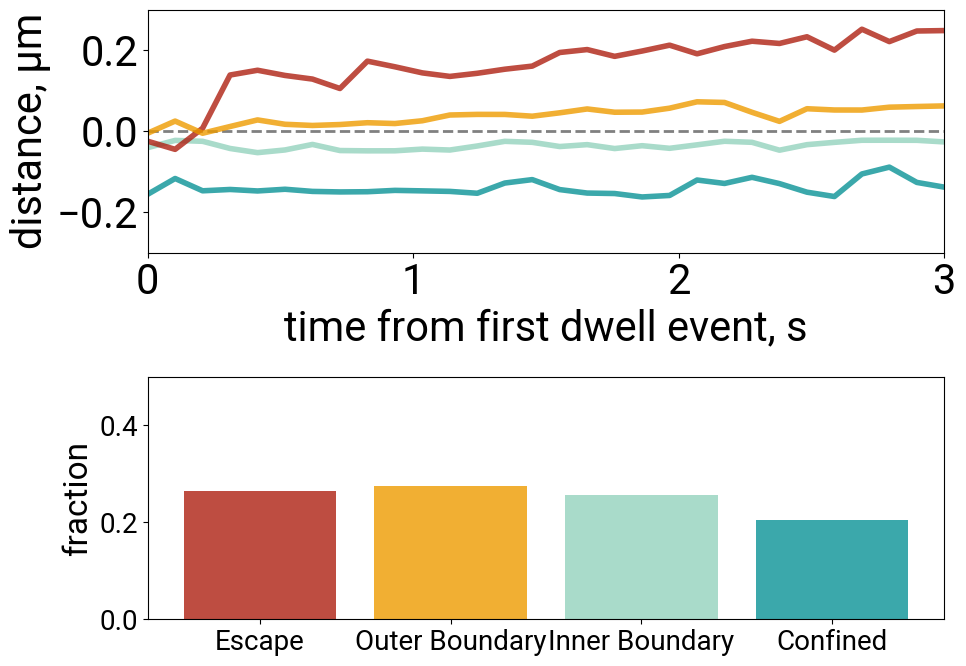

In [ ]:
def create_combined_representative_cluster_trajectory(cluster_df, cluster_labels, color_map, save_path=None):
    """
    Creates a combined trajectory plot for each cluster, overlaying all trajectories in the cluster.

    Parameters:
    - cluster_dict (dict): A dictionary containing cluster information and associated dataframes.
    """
    fig, ax = plt.subplots(2, 1 ,figsize=(10, 7))
    unique_labels = np.unique(cluster_labels)
    common_time = np.linspace(0, 3, 3*10)  # Common time vector for interpolation
    # Plot the trajectory at the top
    for label in unique_labels:
        label_df = cluster_df[cluster_df['cluster_label'] == label]
        rep_df = label_df.iloc[[0]]['representative_trace'].values[0]
        plot_label = label_df['plot_labels'].values[0]
        rank = label_df['rank'].values[0]
        time = rep_df['t'].values
        
        distance = rep_df['distance_um'].values
        interp_distance = np.interp(common_time, time, distance)

        ax[0].plot(common_time, interp_distance, lw=4, alpha=0.8, label=plot_label, c=color_map[label])
        ax[0].set_xlim(0, trace_df['t'].max())

    ax[0].axhline(y=0, color='gray', linestyle='--', lw=2, zorder=-1)
    ax[0].set_xlabel("time from first dwell event, s", fontsize=30)
    ax[0].set_ylabel("distance, μm", fontsize=30)
    ax[0].tick_params(axis='both', which='major', labelsize=30)

    ax[0].set_yticks(np.arange(-0.6, 0.6, 0.2))
    
    # Find the maximum y-axis limit across all clusters
    max_y = max([np.max(np.abs(np.interp(common_time, cluster_df[cluster_df['cluster_label'] == label].iloc[[0]]['representative_trace'].values[0]['distance_um'].values,
                                                      cluster_df[cluster_df['cluster_label'] == label].iloc[[0]]['representative_trace'].values[0]['t'].values))) for label in unique_labels])
    print(f"Max y-axis limit: {max_y}")
    # Set y-axis limit slightly above the maximum value for better visualization
    y_limit = np.ceil(max_y) / 10 + 0.0

    ax[0].set_ylim(-y_limit, y_limit)
    ax[0].set_xlim(0, 3.0)
    ax[0].set_xticks(np.arange(0, 4, 1))
    # Get the plot labels in the correct order of rank
    plot_labels = cluster_df.sort_values('rank')['plot_labels'].unique()
    
    # Calculate the fraction of trajectories in each cluster
    cluster_fractions = pd.Series(cluster_labels).value_counts(normalize=True)
    
    # Sort fractions by rank to match plot_labels and color_map order
    cluster_rank_map = cluster_df.set_index('cluster_label')['rank'].to_dict()
    cluster_fractions = cluster_fractions.sort_index(key=lambda x: x.map(cluster_rank_map))

    # Get colors sorted by rank
    sorted_colors = [color for _, color in sorted(color_map.items(), key=lambda item: cluster_rank_map[item[0]])]

    # Plot the bar chart of cluster fractions
    ax[1].bar(plot_labels, cluster_fractions.values, color=sorted_colors, alpha=0.8)
    ax[1].set_xlabel("Cluster Label", fontsize=24)
    ax[1].set_ylabel("Fraction of Trajectories", fontsize=24)
    ax[1].tick_params(axis='both', which='major', labelsize=20)
    ax[1].set_xticks(cluster_fractions.index)
    
    ax[1].set_xlabel("")
    ax[1].set_ylabel("fraction")
    
    ax[1].set_yticks(np.arange(0, 0.5, 0.2))
    ax[1].set_ylim(0, 0.5)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
        print(f"Combined trajectory plot saved to {save_path}")
        plt.show()

create_combined_representative_cluster_trajectory(cluster_df, cluster_labels, color_map, save_path=f'result/combined_trajectories/{exp_name.split("_FOV")[0]}_combined_cluster_trajectories.svg')

Combined trajectory plot saved to result/combined_trajectories/20220629-FL_2x_puro_test.png


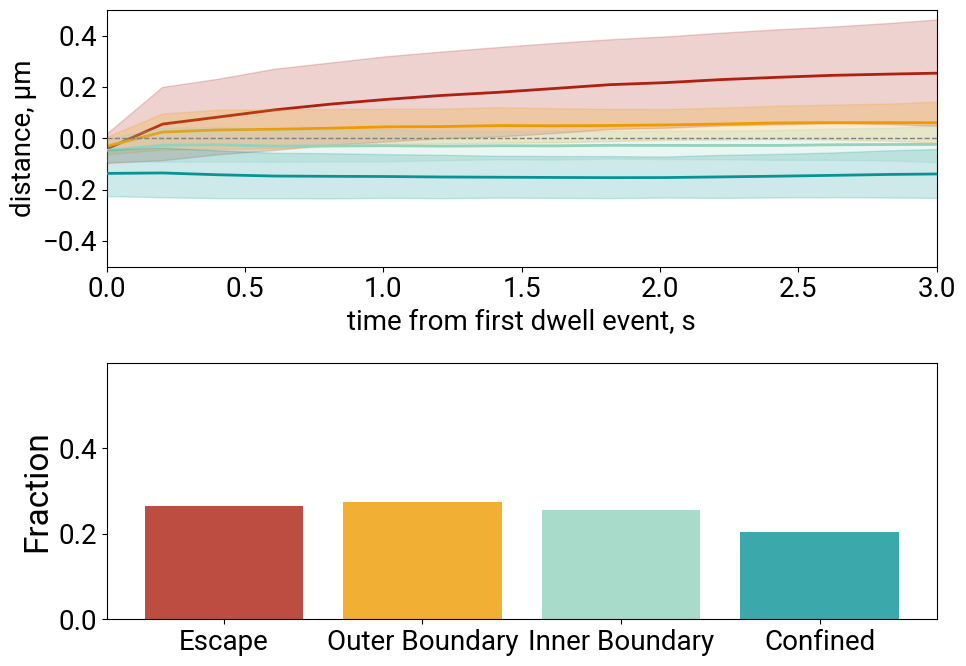

In [ ]:
def create_combined_representative_cluster_trajectory(cluster_df, cluster_labels, color_map, save_path=None):
    """
    Creates a combined trajectory plot for each cluster, overlaying all trajectories in the cluster.

    Parameters:
    - cluster_dict (dict): A dictionary containing cluster information and associated dataframes.
    """
    fig, ax = plt.subplots(2, 1 ,figsize=(10, 7))
    
    # Plot the trajectory at the top
    plot_combined_trajectories(cluster_labels, cluster_df, color_map, t_max, ax=ax[0])
    
    ax[0].set_ylim(-0.5, 0.5)
    ax[0].set_xlim(0, trace_df['t'].max())
    
    # Get the plot labels in the correct order of rank
    plot_labels = cluster_df.sort_values('rank')['plot_labels'].unique()
    
    # Calculate the fraction of trajectories in each cluster
    cluster_fractions = pd.Series(cluster_labels).value_counts(normalize=True)
    
    # Sort fractions by rank to match plot_labels and color_map order
    cluster_rank_map = cluster_df.set_index('cluster_label')['rank'].to_dict()
    cluster_fractions = cluster_fractions.sort_index(key=lambda x: x.map(cluster_rank_map))

    # Get colors sorted by rank
    sorted_colors = [color for _, color in sorted(color_map.items(), key=lambda item: cluster_rank_map[item[0]])]
    
    # Plot the bar chart of cluster fractions
    ax[1].bar(plot_labels, cluster_fractions.values, color=sorted_colors, alpha=0.8)
    ax[1].set_xlabel("Cluster Label", fontsize=24)
    ax[1].set_ylabel("Fraction of Trajectories", fontsize=24)
    ax[1].tick_params(axis='both', which='major', labelsize=20)
    ax[1].set_xticks(cluster_fractions.index)
    
    ax[1].set_xlabel("")
    ax[1].set_ylabel("Fraction")

    ax[1].set_yticks(np.arange(0, 0.5, 0.2))
    ax[1].set_ylim(0, 0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Combined trajectory plot saved to {save_path}")
        plt.show()
        
    cluster_fractions_df = pd.DataFrame({
        'Cluster Label': plot_labels,
        'Fraction of Trajectories': cluster_fractions.values
    })
    
    return cluster_fractions_df
    
cluster_fractions_df = create_combined_representative_cluster_trajectory(cluster_df, cluster_labels, color_map, save_path=f'result/combined_trajectories/{exp_name.split("_FOV")[0]}_test.png')

cluster_fractions_df.to_csv(f'result/csv/{data_name}_cluster_fractions.csv', index=False)

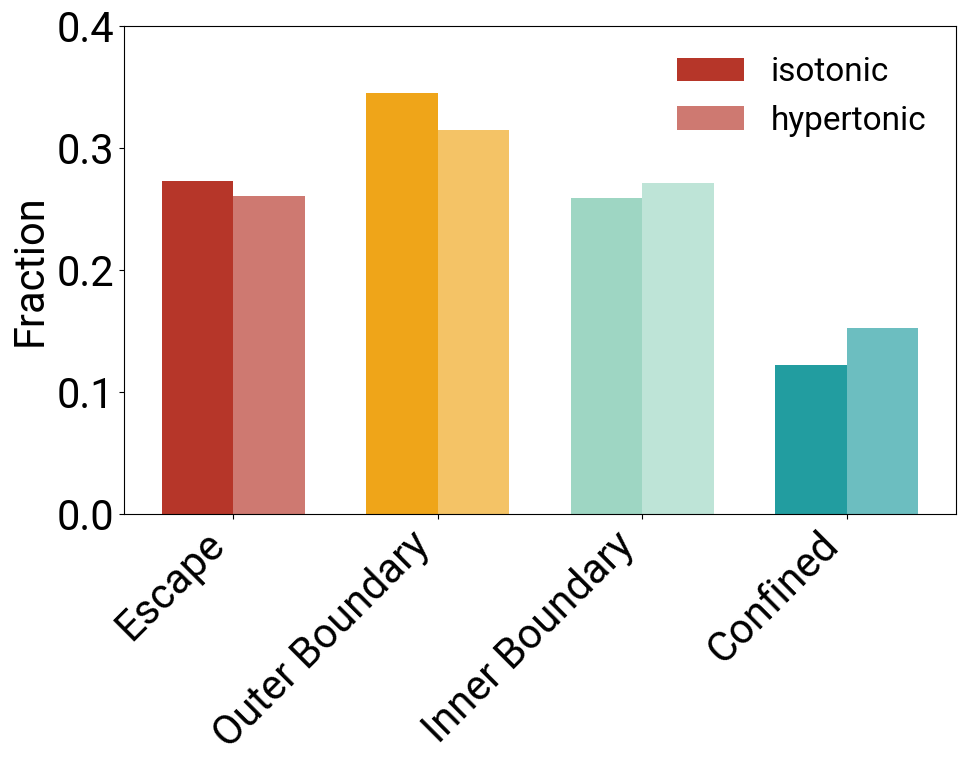

In [ ]:
csv_folder = 'result/csv'
data_to_compare = ['mRNA-1x', 'mRNA_2x']
data_labels = ['isotonic', 'hypertonic']
dfs_to_compare = []

for data_name in data_to_compare:
    csv_path = os.path.join(csv_folder, f"{data_name}_cluster_fractions.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df['Dataset'] = data_name  # Add a column to identify the dataset
        dfs_to_compare.append(df)
    else:
        print(f"Warning: {csv_path} not found. Skipping this dataset.")

# Update color map based on plot_labels
new_color_map = {
    'Escape': color_map[0],
    'Int.-Out': color_map[1],
    'Int.-In': color_map[2],
    'Confined': color_map[3],
    }

cluster_rank_map = cluster_df.set_index('cluster_label')['rank'].to_dict()
sorted_colors = [color for _, color in sorted(color_map.items(), key=lambda item: cluster_rank_map[item[0]])]

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 8))

# Combine the dataframes for easier plotting
if dfs_to_compare:
    combined_df = pd.concat(dfs_to_compare)
    # Add color to the combined df
    combined_df['Color'] = combined_df['Cluster Label'].map(new_color_map)
    
    # Get unique labels and datasets
    labels = combined_df['Cluster Label'].unique()
    datasets = combined_df['Dataset'].unique()
    
    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars
    
    # Create a bar for each dataset
    for i, dataset in enumerate(datasets):
        dataset_df = combined_df[combined_df['Dataset'] == dataset]
        # Ensure the fractions are in the same order as the labels
        fractions = [dataset_df[dataset_df['Cluster Label'] == label]['Fraction of Trajectories'].values[0] for label in labels]

        # Calculate position for each bar
        position = x - width/2 + i * width
        
        # Set alpha: higher for the first, lower for subsequent
        alpha = 0.9 if i == 0 else 0.6
        
        ax.bar(position, fractions, width, label=data_labels[i], 
               color=sorted_colors, alpha=alpha)

    # Add some text for labels, title and axes ticks
    ax.set_ylabel("Fraction", fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=30)
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_yticks(np.arange(0, 0.5, 0.1))
    ax.set_ylim(0, 0.4)

    ax.legend(fontsize=24, title_fontsize=26, frameon=False)
    plt.tight_layout()
    plt.savefig(f'result/combined_trajectories/comparison_{data_to_compare[0]}_vs_{data_to_compare[1]}.svg', dpi=300, bbox_inches='tight', format='svg')
    plt.show()

In [ ]:
# combined_df